<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 06c — Upload high-confidence clips to the platform

Sibling of `06_upload_to_platform.ipynb` and `06_b_upload_uncertainty_to_platform.ipynb`.

Where `06b` ships the **most uncertain** clips (closest to the trained
threshold, for active labeling), this notebook ships the **most
confident** clips on each side: the top-N rows our zh smart-turn model
is most sure are `continuation`, and the top-N it is most sure are
`end_of_turn`.

Pulls every scored candidate from `candidates_scored.parquet`
(produced by `04_score_own_model.ipynb`) and:

1. Drops the unscored sentinel (`model_pred == -1`) and reserved
   test-set sessions (so the frozen test split stays out of training
   uploads — same guard as `06`).
2. Computes `confidence` as the model's probability of its **predicted**
   label (`model_prob` for end_of_turn picks, `1 - model_prob` for
   continuation picks). The records-UI confidence column reads "how
   sure we are of the label we wrote."
3. Picks the top `COUNT_PER_LABEL` rows of each predicted label by
   confidence (defaults to 100 per side, i.e. 200 clips total).
4. Uploads each clip as a `pre_labeled` annotation — the records UI
   orders auto-labelled rows by confidence ASC, so these high-confidence
   picks land at the **bottom** of the triage list (reviewers see them
   last; they're meant for fast green-light review, not active
   relabelling).

In [67]:
from __future__ import annotations

import hashlib
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import soundfile as sf
from tqdm.auto import tqdm

MINING_ROOT  = Path("../../datasets/smart-turn-zh-mining").resolve()
SCORED_IN    = MINING_ROOT / "candidates_scored.parquet"
WAV_DIR      = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

# Load WAVEKAT_* from a `.env` walking up from this notebook (same pattern
# as 06 / 06b). `override=False` so an already-exported shell value wins.
try:
    from dotenv import find_dotenv, load_dotenv
    dotenv_path = find_dotenv(usecwd=True)
    if dotenv_path:
        load_dotenv(dotenv_path, override=False)
        print(f"loaded .env  : {Path(dotenv_path).name} (from {Path(dotenv_path).parent.name}/)")
    else:
        print("loaded .env  : (none found — relying on shell environment)")
except ImportError:
    print("loaded .env  : (python-dotenv not installed — relying on shell environment)")

PLATFORM_BASE_URL = os.environ.get("WAVEKAT_API_URL", "https://localhost:5020").rstrip("/")
PLATFORM_TOKEN    = os.environ.get("WAVEKAT_API_TOKEN")
PROJECT_ID        = os.environ.get("WAVEKAT_PROJECT_ID")

# How many rows per predicted label. Default 100 + 100 = 200 clips total.
COUNT_PER_LABEL = int(os.environ.get("COUNT_PER_LABEL", "10"))
# Belt-and-suspenders cap on the final upload. Same env-var name as 06/06b
# so a smoke-test override (e.g. MAX_UPLOADS=10) keeps working.
MAX_UPLOADS = int(os.environ.get("MAX_UPLOADS", "100000"))

LABEL_KEY_BY_PRED = {0: "continuation", 1: "end_of_turn"}

# Sessions reserved for the frozen real-distribution test set (per
# notebooks/smart-turn/docs/04-0501-0502-models.md "Gap 1"). Mirror of
# the list in `06_upload_to_platform.ipynb` — these WAVs back the
# hand-audited test labels and must NEVER ship as training annotations.
RESERVED_TEST_SESSIONS = frozenset({
    "CTS-CN-F2F-2019-11-15-37",
    "CTS-CN-F2F-2019-11-15-747",
    "CTS-CN-F2F-2019-11-15-896",
    "CTS-CN-F2F-2019-11-15-511",
    "CTS-CN-F2F-2019-11-15-455",
    "CTS-CN-F2F-2019-11-15-1282",
    "CTS-CN-F2F-2019-11-15-1208",
    "CTS-CN-F2F-2019-11-15-935",
    "CTS-CN-F2F-2019-11-15-722",
    "CTS-CN-F2F-2019-11-15-298",
    "CTS-CN-F2F-2019-11-15-1374",
    "CTS-CN-F2F-2019-11-15-844",
    "CTS-CN-F2F-2019-11-15-730",
    "CTS-CN-F2F-2019-11-15-860",
    "CTS-CN-F2F-2019-11-15-239",
    "CTS-CN-F2F-2019-11-15-388",
    "CTS-CN-F2F-2019-11-15-311",
    "CTS-CN-F2F-2019-11-15-1355",
    "CTS-CN-F2F-2019-11-15-1165",
    "CTS-CN-F2F-2019-11-15-961",
})

print(f"scored parquet    : {SCORED_IN.name} (exists={SCORED_IN.exists()})")
print(f"wav dir           : {WAV_DIR.name}/  (exists={WAV_DIR.exists()})")
print(f"platform          : {PLATFORM_BASE_URL}")
print(f"token set         : {bool(PLATFORM_TOKEN)}")
print(f"project id        : {PROJECT_ID or '(unset — set WAVEKAT_PROJECT_ID)'}")
print(f"per-label count   : {COUNT_PER_LABEL}  (env: COUNT_PER_LABEL)")
print(f"max uploads       : {MAX_UPLOADS}")
print(f"reserved sessions : {len(RESERVED_TEST_SESSIONS)} (held back for frozen test set)")
print("✅ config loaded")

Task was destroyed but it is pending!
task: <Task pending name='Task-385' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-386' coro=<Kernel.shell_main() running at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/eason/Developer/_wavekat/wavekat-lab/.venv/lib/python3.12/site-packages/IPython/core/compilerop.py:86: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return compile(source, filename, symbol, self.flags | PyCF_ONLY_AST, 1)
Task was destroyed but it is pending!
task: <Task pending name='Task-386' coro=<Kernel.shell_main() running at /Users/eason/Developer/_

loaded .env  : .env (from wavekat-lab/)
scored parquet    : candidates_scored.parquet (exists=True)
wav dir           : WAV/  (exists=True)
platform          : https://platform.wavekat.com
token set         : True
project id        : 3040f61d-f6cb-4dd7-87e2-22b575d64a3c
per-label count   : 10  (env: COUNT_PER_LABEL)
max uploads       : 100000
reserved sessions : 20 (held back for frozen test set)
✅ config loaded


In [68]:
# Ping /api/me — the cheapest possible "does my token work?" check.
# A 401 here means the token is wrong / revoked / minted against a
# different platform host.
if not PLATFORM_TOKEN:
    raise SystemExit("WAVEKAT_API_TOKEN is unset — mint one with `wk login --base-url …` and export it.")

session = requests.Session()
session.headers.update({
    "Authorization": f"Bearer {PLATFORM_TOKEN}",
    "User-Agent": "wavekat-lab/06c-upload-high-confidence",
})

me = session.get(f"{PLATFORM_BASE_URL}/api/me", timeout=10)
if me.status_code == 401:
    raise SystemExit(
        f"401 from {PLATFORM_BASE_URL}/api/me — token rejected.\n"
        f"  • Was the token minted against this host? (tokens are scoped to a single platform.)\n"
        f"  • Has it been revoked? Mint a fresh one: `WK_BASE_URL={PLATFORM_BASE_URL} wk login`."
    )
me.raise_for_status()
me_json = me.json()
print(f"authenticated as : {me_json.get('login')}  (role={me_json.get('role')}, id={me_json.get('id')})")
print("✅ token works")

authenticated as : wavekat-eason  (role=root, id=220911746)
✅ token works


In [69]:
# Verify the destination project + its active label set. Split out from the
# /me ping so a project-config issue doesn't masquerade as an auth failure.
if not PROJECT_ID:
    raise SystemExit("WAVEKAT_PROJECT_ID is unset — set it to the destination project's id.")

proj = session.get(f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}", timeout=10)
if proj.status_code == 404:
    raise SystemExit(
        f"404 on project {PROJECT_ID} — either the id is wrong, or your account "
        f"isn't a member of that project (the API returns 404, not 403, to avoid leaking existence)."
    )
proj.raise_for_status()
proj_json = proj.json()
print(f"project          : {proj_json.get('name')}  (role={proj_json.get('myRoleInProject')})")
active_label_set_id = proj_json.get("activeLabelSetId")
if not active_label_set_id:
    raise SystemExit("project has no active label set — pick one in the platform UI first.")

ls = session.get(f"{PLATFORM_BASE_URL}/api/label-sets/{active_label_set_id}", timeout=10)
ls.raise_for_status()
ls_json = ls.json()
label_keys = {l["key"] for l in ls_json.get("labels", [])}
missing = set(LABEL_KEY_BY_PRED.values()) - label_keys
if missing:
    raise SystemExit(
        f"active label set '{ls_json.get('name')}' is missing required keys: {sorted(missing)}"
    )
print(f"label set        : {ls_json.get('name')}  (keys: {sorted(label_keys)})")
print("✅ project + label set verified")

project          : MagicData-RAMC - Auto Label #3  (role=root)
label set        : Turn Detection V1  (keys: ['continuation', 'end_of_turn'])
✅ project + label set verified


In [70]:
# Fetch every annotation already on the platform for this project, so we
# can skip clips we've previously uploaded. Without this, re-running the
# upload after a partial failure (or a re-pick with a different
# COUNT_PER_LABEL) would create duplicate annotations on the same
# (session, start, end) span — and the platform returns 409 on those.
#
# **Includes every review status** — accepted, rejected, pending,
# need_fix — so a re-run never re-uploads a clip that already exists in
# any state. A rejected annotation is still a row on the platform and
# will still 409 on insert, so we have to count it as "already there".
# We deliberately pass no `reviewStatus` / `source` filters; the API
# returns the full set when those are omitted.
#
# We page through `/api/projects/{id}/annotations` and key each row on
# (session_id, round(start, 2), round(end, 2)). Two normalisations
# matter:
#   • `fileName` from the API is the *original* filename (e.g.
#     `CTS-CN-F2F-2019-11-15-1469.wav`) but our parquet uses bare session
#     ids. Strip `.wav` so the keys align — without this every dedupe
#     lookup misses and the upload loop hits 409s.
#   • Round to 0.01 s — JSON-serialised floats aren't safe for exact
#     equality, and 10 ms is well below the records-UI bucket size.
#
# Set DEDUPE_AGAINST_PLATFORM=0 to skip (e.g. when seeding a fresh
# project where the round-trip is wasted work).
import os.path
from collections import Counter

DEDUPE_AGAINST_PLATFORM = os.environ.get("DEDUPE_AGAINST_PLATFORM", "1") != "0"
DEDUPE_PAGE_SIZE        = int(os.environ.get("DEDUPE_PAGE_SIZE", "200"))

def _normalize_session(name) -> str:
    """Map a platform `fileName` (e.g. `foo.wav`) to our session id (`foo`).
    Idempotent — bare session ids round-trip unchanged."""
    if name is None:
        return ""
    base = os.path.basename(str(name))
    stem, _ext = os.path.splitext(base)
    return stem

def _dedupe_key(session_id, start_s, end_s) -> tuple[str, float, float]:
    return (_normalize_session(session_id), round(float(start_s), 2), round(float(end_s), 2))

existing_keys: set[tuple[str, float, float]] = set()
status_counter: Counter = Counter()
source_counter: Counter = Counter()

if DEDUPE_AGAINST_PLATFORM:
    page = 1
    fetched = 0
    total = None
    pbar = tqdm(desc="existing annotations", unit="ann")
    while True:
        r = session.get(
            f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/annotations",
            params={"page": page, "pageSize": DEDUPE_PAGE_SIZE},
            timeout=30,
        )
        r.raise_for_status()
        body = r.json()
        anns = body.get("annotations", [])
        if total is None:
            total = int(body.get("total", 0))
            pbar.total = total
            pbar.refresh()
        if not anns:
            break
        for a in anns:
            sid = (
                a.get("fileName")
                or (a.get("file") or {}).get("name")
                or (a.get("file") or {}).get("originalFilename")
            )
            start_s = a.get("startSec")
            end_s   = a.get("endSec")
            if sid is None or start_s is None or end_s is None:
                continue
            existing_keys.add(_dedupe_key(sid, start_s, end_s))
            status_counter[a.get("reviewStatus") or "(none)"] += 1
            source_counter[a.get("source") or "(none)"] += 1
        fetched += len(anns)
        pbar.update(len(anns))
        if total is not None and fetched >= total:
            break
        page += 1
    pbar.close()
    print(f"existing annotations on platform : {len(existing_keys):,} unique (session, start, end) keys")
    print(f"server-reported total            : {total}  (fetched {fetched})")
    if status_counter:
        print(f"by reviewStatus  : {dict(status_counter)}")
    if source_counter:
        print(f"by source        : {dict(source_counter)}")
    if existing_keys:
        sample = next(iter(existing_keys))
        print(f"sample key (post-normalise) : {sample!r}")
else:
    print("DEDUPE_AGAINST_PLATFORM=0 — skipping platform fetch (no dedupe will run)")
print("✅ existing-annotation index ready")

existing annotations: 0ann [00:00, ?ann/s]

existing annotations on platform : 2,810 unique (session, start, end) keys
server-reported total            : 2816  (fetched 2816)
by reviewStatus  : {'(none)': 155, 'approved': 2449, 'rejected': 212}
by source        : {'pre_labeled': 2816}
sample key (post-normalise) : ('CTS-CN-F2F-2019-11-15-1368', 1341.94, 1344.67)
✅ existing-annotation index ready


In [71]:
# Build the upload queue: top `COUNT_PER_LABEL` rows by confidence on
# each predicted label, after dropping clips already on the platform.
#
#   confidence = model's probability of its *predicted* label
#       • predicted end_of_turn   → confidence = model_prob
#       • predicted continuation → confidence = 1 - model_prob
#
# Filtering against `existing_keys` happens *before* the top-N pick so
# re-runs always queue the next-most-confident *new* clips — we don't
# silently shrink to <N just because the previous run already grabbed
# the highest-confidence rows.
scored = pd.read_parquet(SCORED_IN)
n_total = len(scored)

# Drop the unscored sentinel notebook 04 writes when a session WAV is
# missing (model_pred = -1).
scored = scored[scored["model_pred"] != -1].copy()
n_after_sentinel = len(scored)

# Drop reserved-test sessions — these WAVs back the frozen test split.
is_reserved = scored["session_id"].astype(str).isin(RESERVED_TEST_SESSIONS)
n_reserved_dropped = int(is_reserved.sum())
scored = scored[~is_reserved].copy()

# Drop clips already uploaded to the platform (cell 05 built
# `existing_keys`). When DEDUPE_AGAINST_PLATFORM=0, the set is empty and
# this is a no-op.
n_before_dedupe = len(scored)
if existing_keys:
    candidate_keys = list(zip(
        scored["session_id"].astype(str),
        scored["clip_start_s"].astype(float).round(2),
        scored["clip_end_s"].astype(float).round(2),
    ))
    keep_mask = np.array([k not in existing_keys for k in candidate_keys])
    scored = scored[keep_mask].copy()
n_dedupe_dropped = n_before_dedupe - len(scored)

scored["duration_s"] = (scored["clip_end_s"] - scored["clip_start_s"]).astype(float)
mp = scored["model_prob"].astype(float)
is_eot = scored["model_pred"] == 1
scored["confidence"] = np.where(is_eot, mp, 1.0 - mp)

# Top-N per side by confidence.
picks = []
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    side = scored[scored["model_pred"] == pred]
    top  = side.sort_values("confidence", ascending=False, kind="mergesort").head(COUNT_PER_LABEL)
    picks.append(top)

to_upload = (
    pd.concat(picks, ignore_index=True)
      .head(MAX_UPLOADS)
      .reset_index(drop=True)
)

print(f"scored rows total : {n_total:,}")
print(f"after sentinel    : {n_after_sentinel:,}  (-{n_total - n_after_sentinel} unscored)")
print(f"after reserved    : {n_before_dedupe:,}  (-{n_reserved_dropped} reserved-session rows)")
print(f"after dedupe      : {len(scored):,}  (-{n_dedupe_dropped} already on platform)")
print(f"per-label target  : {COUNT_PER_LABEL}")
print(f"queued for upload : {len(to_upload):,}  (cap MAX_UPLOADS={MAX_UPLOADS})")
print("by predicted label (queued):")
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    sub = to_upload[to_upload["model_pred"] == pred]
    if len(sub):
        print(
            f"    {label_key:>12} : {len(sub):>4}  "
            f"conf[min,med,max]=[{sub['confidence'].min():.3f}, "
            f"{sub['confidence'].median():.3f}, {sub['confidence'].max():.3f}]  "
            f"prob[min,med,max]=[{sub['model_prob'].min():.3f}, "
            f"{sub['model_prob'].median():.3f}, {sub['model_prob'].max():.3f}]"
        )
        if len(sub) < COUNT_PER_LABEL:
            print(f"    {' ' * 12}    ⚠️  pool exhausted — only {len(sub)} new rows available on this side")
    else:
        print(f"    {label_key:>12} : 0  — no rows on this side (check OURS scoring run / dedupe)")

n_disagree = int((to_upload["model_pred"] != to_upload["label"]).sum())
print(f"model vs structural disagreement : {n_disagree} / {len(to_upload)}")
print(f"unique sessions  : {to_upload['session_id'].nunique()}")

# Notes the upload cell will attach to each annotation. Per-row so the
# upload loop can treat this notebook the same way as the 06 "raw-source
# pick" path (which also sets `_notes` per row).
to_upload["_notes"] = to_upload.apply(
    lambda r: (
        "smart-turn-mining 06c high-confidence pick\n"
        f"model_prob={float(r['model_prob']):.4f}, "
        f"confidence={float(r['confidence']):.4f}, "
        f"predicted={LABEL_KEY_BY_PRED[int(r['model_pred'])]}, "
        f"structural_label={r.get('label')}, "
        f"source={r.get('source')}, "
        f"duration={float(r['duration_s']):.2f}s"
    ),
    axis=1,
)
print("✅ upload queue ready")

scored rows total : 33,943
after sentinel    : 33,943  (-0 unscored)
after reserved    : 32,253  (-1690 reserved-session rows)
after dedupe      : 29,766  (-2487 already on platform)
per-label target  : 10
queued for upload : 20  (cap MAX_UPLOADS=100000)
by predicted label (queued):
    continuation :   10  conf[min,med,max]=[0.929, 0.929, 0.929]  prob[min,med,max]=[0.071, 0.071, 0.071]
     end_of_turn :   10  conf[min,med,max]=[0.910, 0.910, 0.911]  prob[min,med,max]=[0.910, 0.910, 0.911]
model vs structural disagreement : 1 / 20
unique sessions  : 18
✅ upload queue ready


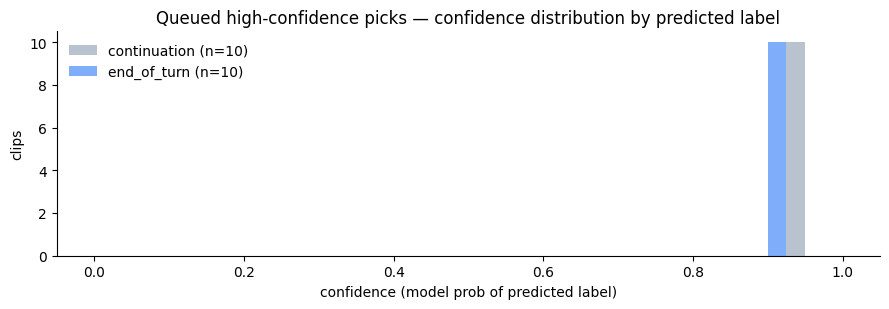

duration min/p50/p90/max : 1.01s / 2.46s / 4.42s / 4.47s
all clips ≤ 8 s — match the model's input window
✅ confidence chart drawn


In [72]:
# Pre-flight chart: confidence distribution of the queued sample, per
# predicted label. High-confidence picks should sit far to the right —
# if the per-side `max` is well below 1.0, the model never reached high
# certainty on that side and reviewers should expect noisier auto-labels.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.2))
bins = np.linspace(0, 1, 41)
palette = {"continuation": "#94a3b8", "end_of_turn": "#3b82f6"}
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    sub = to_upload[to_upload["model_pred"] == pred]["confidence"]
    if len(sub):
        ax.hist(sub, bins=bins, alpha=0.65, color=palette[label_key],
                label=f"{label_key} (n={len(sub)})")
ax.set_xlabel("confidence (model prob of predicted label)")
ax.set_ylabel("clips")
ax.set_title("Queued high-confidence picks — confidence distribution by predicted label")
ax.legend(loc="upper left", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

# Duration sanity print — the model sees the trailing 8 s, so anything
# longer is upstream-only context the platform's bucketing will lump
# into its ≥10s bin.
durations = to_upload["duration_s"]
if len(durations):
    print(f"duration min/p50/p90/max : "
          f"{durations.min():.2f}s / {durations.median():.2f}s / "
          f"{durations.quantile(0.90):.2f}s / {durations.max():.2f}s")
    n_over_8 = int((durations > 8.0).sum())
    if n_over_8:
        print(f"⚠️  {n_over_8} clip(s) exceed 8 s — platform will bucket these as ≥10s")
    else:
        print("all clips ≤ 8 s — match the model's input window")
print("✅ confidence chart drawn")

In [73]:
# Per-session helpers — same as 06 / 06b: hash the WAV once, cache the
# file id, slice + re-emit a 16-bit mono PCM WAV per clip.
import functools

_HASH_CHUNK = 1024 * 1024  # 1 MB

@functools.lru_cache(maxsize=None)
def session_wav_meta(session_id: str) -> dict:
    path = WAV_DIR / f"{session_id}.wav"
    info = sf.info(str(path))
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(_HASH_CHUNK)
            if not chunk:
                break
            h.update(chunk)
    return {
        "path": path,
        "sha256": h.hexdigest(),
        "sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "duration_sec": float(info.frames) / float(info.samplerate),
    }

@functools.lru_cache(maxsize=None)
def upsert_file(session_id: str) -> str:
    """Create-or-get the platform `files` row for a session WAV; return its id."""
    meta = session_wav_meta(session_id)
    body = {
        "name": session_id,
        "originalFilename": f"{session_id}.wav",
        "sha256": meta["sha256"],
        "durationSec": meta["duration_sec"],
        "sampleRate": meta["sample_rate"],
        "channelCount": meta["channels"],
    }
    r = session.post(
        f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/files",
        json=body, timeout=15,
    )
    r.raise_for_status()
    j = r.json()
    return j["id"]

def slice_wav_bytes(session_id: str, start_s: float, end_s: float) -> bytes:
    meta = session_wav_meta(session_id)
    sr = meta["sample_rate"]
    start  = max(0, int(start_s * sr))
    frames = max(1, int((end_s - start_s) * sr))
    audio, _ = sf.read(str(meta["path"]), start=start, frames=frames,
                       dtype="float32", always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    buf = io.BytesIO()
    sf.write(buf, audio, sr, format="WAV", subtype="PCM_16")
    return buf.getvalue()

print("✅ helpers ready")

✅ helpers ready


In [74]:
# Preview the first N rows of `to_upload` as inline audio players — the
# last sanity check before firing the upload loop. These should sound
# unambiguous: the end_of_turn picks like clean turn-yields, the
# continuation picks like clear mid-thought beats. If any sound
# borderline, the model is overconfident on that side.
from IPython.display import Audio, display, HTML

PREVIEW_N = int(os.environ.get("PREVIEW_N", "10"))
# Show the top of each predicted-label group so the preview covers both
# sides instead of only the first label that happens to come first.
preview_groups = []
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    sub = to_upload[to_upload["model_pred"] == pred].head(PREVIEW_N // 2 + PREVIEW_N % 2)
    preview_groups.append(sub)
preview = pd.concat(preview_groups).head(PREVIEW_N)
print(f"previewing {len(preview)} of {len(to_upload)} queued clips  (env: PREVIEW_N)")

for i, row in preview.iterrows():
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")
    structural = int(row["label"])
    structural_key = LABEL_KEY_BY_PRED.get(structural, str(structural))
    disagree = " ⚠ disagrees with structural" if structural != pred else ""
    wav_bytes = slice_wav_bytes(sid, start_s, end_s)
    header = (
        f"[{i + 1:02d}] predicted={label_key}  "
        f"conf={float(row['confidence']):.3f}  "
        f"prob={float(row['model_prob']):.3f}  "
        f"structural={structural_key}{disagree}  "
        f"dur={end_s - start_s:.2f}s  "
        f"{sid} @ {start_s:.2f}–{end_s:.2f}s"
    )
    display(HTML(f"<div style='font-family:ui-monospace,monospace;font-size:12px;margin-top:6px'>{header}</div>"))
    if asr_text:
        display(HTML(f"<div style='font-size:13px;color:#475569;margin-bottom:2px'>asr: {asr_text}</div>"))
    display(Audio(data=wav_bytes))
print("✅ preview rendered — scroll up to listen, then run the upload cell when satisfied")

previewing 10 of 20 queued clips  (env: PREVIEW_N)


✅ preview rendered — scroll up to listen, then run the upload cell when satisfied


In [75]:
# Upload loop. Mirrors 06b's parallelised loop — same pre-warm + thread-
# pool fan-out. Per-row `_notes` was set during queue building, so the
# loop just forwards it to the platform.
#
# HTTP 409 is treated as a *success* with `status="exists"`: it means the
# platform already has an annotation for this exact (file, start, end)
# span, so the desired end-state is already true and the row should not
# be counted as a failure. The dedupe cell should catch most of these
# upfront, but rounding edges + races leave a few; this keeps re-runs
# idempotent.
import concurrent.futures
from requests.adapters import HTTPAdapter

_adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64, max_retries=0)
session.mount("https://", _adapter)
session.mount("http://", _adapter)

unique_sessions = sorted(set(to_upload["session_id"].astype(str)))
print(f"pre-warming {len(unique_sessions)} session file(s)…")
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as _ex:
    list(tqdm(_ex.map(upsert_file, unique_sessions),
              total=len(unique_sessions), desc="files", unit="file"))

UPLOAD_WORKERS = int(os.environ.get("UPLOAD_WORKERS", "16"))


def _upload_one(row_tuple):
    _, row = row_tuple
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    confidence = float(row["confidence"])
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")[:4000]
    notes_override = row.get("_notes")
    notes = notes_override if isinstance(notes_override, str) and notes_override else (
        f"smart-turn-mining 06c high-confidence pick\n"
        f"model_prob={float(row['model_prob']):.4f}, confidence={confidence:.4f}"
    )

    try:
        file_id = upsert_file(sid)
        create_body = {
            "labelKey":   label_key,
            "startSec":   start_s,
            "endSec":     end_s,
            "asrText":    asr_text or None,
            "source":     "pre_labeled",
            "confidence": confidence,
            "notes":      notes,
        }
        r = session.post(
            f"{PLATFORM_BASE_URL}/api/files/{file_id}/annotations",
            json=create_body, timeout=30,
        )
        # 409 = annotation for this (file, start, end) already exists.
        # Server returns the existing row's id in the body so we can
        # report it back to the caller without leaving the loop in a
        # failure state.
        if r.status_code == 409:
            try:
                existing_id = r.json().get("id")
            except Exception:
                existing_id = None
            return {
                "ok": True, "status": "exists", "annotation_id": existing_id,
                "label": label_key, "confidence": confidence, "bytes": 0,
                "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            }
        r.raise_for_status()
        ann_id = r.json()["id"]

        wav_bytes = slice_wav_bytes(sid, start_s, end_s)
        u = session.put(
            f"{PLATFORM_BASE_URL}/api/annotations/{ann_id}/clip",
            data=wav_bytes,
            headers={"Content-Type": "audio/wav"},
            timeout=60,
        )
        u.raise_for_status()
        return {
            "ok": True, "status": "created", "annotation_id": ann_id,
            "label": label_key, "confidence": confidence, "bytes": len(wav_bytes),
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
        }
    except requests.HTTPError as e:
        body = getattr(e.response, "text", "")
        return {
            "ok": False, "status": "http_error", "label": label_key,
            "confidence": confidence, "session": sid,
            "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"HTTP {e.response.status_code}: {body[:200]}",
        }
    except Exception as e:
        return {
            "ok": False, "status": "error", "label": label_key,
            "confidence": confidence, "session": sid,
            "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"{type(e).__name__}: {e}",
        }


results: list[dict] = []
ok_count = 0
fail_count = 0
exists_count = 0

rows = list(to_upload.iterrows())
pbar = tqdm(total=len(rows), desc="upload", unit="clip")
with concurrent.futures.ThreadPoolExecutor(max_workers=UPLOAD_WORKERS) as ex:
    for res in ex.map(_upload_one, rows):
        results.append(res)
        if res["ok"]:
            ok_count += 1
            if res.get("status") == "exists":
                exists_count += 1
        else:
            fail_count += 1
        pbar.set_postfix(ok=ok_count, exists=exists_count, fail=fail_count, refresh=False)
        pbar.update(1)
pbar.close()

results_df = pd.DataFrame(results)
created_count = ok_count - exists_count
print(f"created     : {created_count}")
print(f"already-exists (skipped) : {exists_count}")
print(f"failed      : {fail_count}  (workers={UPLOAD_WORKERS})")
if fail_count:
    print("\nfirst failures:")
    display(results_df[~results_df["ok"]].head(5))
print("✅ upload run complete")
results_df.head(20)

pre-warming 18 session file(s)…


files:   0%|          | 0/18 [00:00<?, ?file/s]

upload:   0%|          | 0/20 [00:00<?, ?clip/s]

created     : 12
already-exists (skipped) : 8
failed      : 0  (workers=16)
✅ upload run complete


,ok,status,annotation_id,label,confidence,bytes,session,range
0,True,exists,5924cd04-426e-44f7-a87d-7a4a958fad06,continuation,0.928995,0,CTS-CN-F2F-2019-11-15-1469,1065.07-1066.11
1,True,created,404fba5e-0840-4c93-90b0-676aef16938f,continuation,0.928922,34604,CTS-CN-F2F-2019-11-15-1005,1808.55-1809.63
2,True,created,12596f10-afed-4fcb-bdfe-abfc96733fbe,continuation,0.928922,32426,CTS-CN-F2F-2019-11-15-359,1394.73-1395.74
3,True,created,b03f5f9e-824b-449f-9139-758d200f1bfe,continuation,0.928922,83498,CTS-CN-F2F-2019-11-15-244,1611.47-1614.08
4,True,created,6634124c-2c28-4e45-8e63-6c257663b096,continuation,0.928921,60202,CTS-CN-F2F-2019-11-15-162,518.25-520.13
5,True,created,26fe370a-31b0-46ee-ba42-0c77c497f5ee,continuation,0.928920,55980,CTS-CN-F2F-2019-11-15-1421,1611.18-1612.93
6,True,created,e85ed7fb-4b4a-43c6-9072-d54e6ac9d69a,continuation,0.928919,41772,CTS-CN-F2F-2019-11-15-634,439.50-440.80
7,True,created,0d8aff66-3afb-4457-a522-f01bf85ba957,continuation,0.928919,44332,CTS-CN-F2F-2019-11-15-1094,956.95-958.34
8,True,created,a223d631-f2ba-4995-bde5-d8d986028983,continuation,0.928918,142314,CTS-CN-F2F-2019-11-15-1035,1453.35-1457.79
9,True,created,520f4b78-213f-4479-9916-d72e4c10bf03,continuation,0.928917,97196,CTS-CN-F2F-2019-11-15-1323,490.18-493.22


In [41]:
# Sanity-check: re-fetch the project's auto-labelled rows ordered by
# confidence DESC. The freshly-uploaded high-confidence rows should sit
# near the top of *this* list (the inverse of 06b's verify cell, which
# orders ASC to surface uncertain rows first).
r = session.get(
    f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/annotations",
    params={
        "page": 1,
        "pageSize": 20,
        "source": "auto",
        "orderBy": "confidence",
        "order": "desc",
    },
    timeout=15,
)
r.raise_for_status()
page = r.json()
print(f"project auto-labelled total : {page['total']}")
if page['annotations']:
    cols = ["labelKey", "confidence", "reviewStatus", "startSec", "endSec", "fileName"]
    display(pd.DataFrame(page['annotations'])[cols].head(20))
print("✅ verified via the records-list endpoint")

project auto-labelled total : 2803


,labelKey,confidence,reviewStatus,startSec,endSec,fileName
0,continuation,0.994720,approved,1107.048,1111.072,CTS-CN-F2F-2019-11-15-151
1,continuation,0.994509,approved,1709.264,1713.504,CTS-CN-F2F-2019-11-15-687
2,continuation,0.994509,approved,376.960,381.632,CTS-CN-F2F-2019-11-15-372
3,continuation,0.994509,approved,371.461,374.112,CTS-CN-F2F-2019-11-15-1421
4,continuation,0.994289,approved,1467.136,1471.904,CTS-CN-F2F-2019-11-15-798
5,continuation,0.994289,approved,1311.137,1314.048,CTS-CN-F2F-2019-11-15-577
6,continuation,0.994289,approved,1207.872,1210.720,CTS-CN-F2F-2019-11-15-39
7,continuation,0.994289,approved,950.122,951.776,CTS-CN-F2F-2019-11-15-1165
8,continuation,0.994289,approved,1701.672,1705.984,CTS-CN-F2F-2019-11-15-1323
9,continuation,0.994289,approved,1202.316,1206.816,CTS-CN-F2F-2019-11-15-903


✅ verified via the records-list endpoint
